# LSTM Binary Fall Detection v5 — Training

**Architecture:**
- LSTM → จำแนก 2 class: `fall` / `non_fall`
- Rule-based → กำหนดระดับ A/B/C จาก duration ใน `predict.py`

**ทำไมกลับมา Binary:**
- 3-class (fall/still/non_fall) ไม่เวิร์ค → CSI ตอน "นอนนิ่งหลังล้ม" กับ "นอนปกติ" เหมือนกัน
- Binary ให้ accuracy สูงกว่า (88% vs 72%)
- FallStateTracker จัดการ duration + reset ด้วย rule-based แทน

**ปรับปรุงจาก v3:**
- non_fall ตัดที่ 15 วิ → ลด imbalance
- Oversample fall class ให้สมดุล

**ขั้นตอนก่อน train:**
```bash
python notebooks/preprocess.py   # สร้าง X.npy, y.npy (v5 binary trimmed)
```

## 1. Imports & Config

In [11]:
import os, json, pickle
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# Path
BASE_DIR   = os.path.dirname(os.path.abspath("."))
DATA_DIR   = os.path.join(BASE_DIR, "data", "processed")
MODEL_DIR  = os.path.join(BASE_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

# Config
SEQUENCE_LEN = 5
N_FEATURES   = 416
N_CLASSES    = 2
BATCH_SIZE   = 128  
MAX_EPOCHS   = 100
PATIENCE     = 20
VAL_RATIO    = 0.15
TEST_RATIO   = 0.15
RANDOM_SEED  = 42
LABEL_NAMES  = ["fall", "non_fall"]

MODEL_PATH  = os.path.join(MODEL_DIR, "lstm_binary.h5")
SCALER_PATH = os.path.join(MODEL_DIR, "scaler.pkl")
REPORT_PATH = os.path.join(MODEL_DIR, "training_report.json")
CM_PATH     = os.path.join(MODEL_DIR, "confusion_matrix_binary.png")

np.random.seed(RANDOM_SEED)
print(f"BASE_DIR      : {BASE_DIR}")
print(f"DATA_DIR      : {DATA_DIR}")
print(f"SEQUENCE_LEN  : {SEQUENCE_LEN}")
print(f"N_CLASSES     : {N_CLASSES}")
print(f"LABEL_NAMES   : {LABEL_NAMES}")

BASE_DIR      : /Users/peerawootposh/TDG/fall_detection_backend/ml_service
DATA_DIR      : /Users/peerawootposh/TDG/fall_detection_backend/ml_service/data/processed
SEQUENCE_LEN  : 5
N_CLASSES     : 2
LABEL_NAMES   : ['fall', 'non_fall']


## 2. Load Data

In [12]:
X_win      = np.load(os.path.join(DATA_DIR, "X.npy"))        # (n_windows, 416)
y_win      = np.load(os.path.join(DATA_DIR, "y.npy"))        # (n_windows,)
file_ids   = np.load(os.path.join(DATA_DIR, "file_ids.npy")) # (n_windows,)

unique_labels = np.unique(y_win)
assert set(unique_labels).issubset({0, 1}), \
    f"y มี labels {unique_labels} — ต้องเป็น binary (0/1) รัน preprocess.py v5 ก่อน"

n_files = len(np.unique(file_ids))
print(f"X shape     : {X_win.shape}")
print(f"y shape     : {y_win.shape}")
print(f"Files       : {n_files} recordings\n")
for i, name in enumerate(LABEL_NAMES):
    count = int(np.sum(y_win == i))
    pct   = count / len(y_win) * 100
    bar   = "█" * int(pct / 2)
    print(f"  {name:10s} ({i}): {count:5d} windows ({pct:.1f}%)  {bar}")

X shape     : (7137, 416)
y shape     : (7137,)
Files       : 420 recordings

  fall       (0):  3897 windows (54.6%)  ███████████████████████████
  non_fall   (1):  3240 windows (45.4%)  ██████████████████████


## 3. Normalize Features

In [13]:
# ตรวจและทำความสะอาด NaN/Inf ก่อน scale
nan_count = int(np.isnan(X_win).sum())
inf_count = int(np.isinf(X_win).sum())
print(f"NaN in X_win : {nan_count}")
print(f"Inf in X_win : {inf_count}")

if nan_count > 0 or inf_count > 0:
    print("⚠️  พบค่า NaN/Inf — แทนด้วย 0 (เกิดจาก skewness/kurtosis บน constant signal)")
    X_win = np.nan_to_num(X_win, nan=0.0, posinf=0.0, neginf=0.0)
    print(f"✅ หลังทำความสะอาด: NaN={np.isnan(X_win).sum()}, Inf={np.isinf(X_win).sum()}")
else:
    print("✅ ข้อมูลสะอาด ไม่มี NaN/Inf")

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_win)

# ตรวจอีกครั้งหลัง scale
post_nan = int(np.isnan(X_scaled).sum())
print(f"\nNaN หลัง scale : {post_nan}")
assert post_nan == 0, "ยังมี NaN หลัง scale — ตรวจสอบ data อีกครั้ง"

with open(SCALER_PATH, "wb") as f:
    pickle.dump(scaler, f)

print(f"Scaler saved : {SCALER_PATH}")

NaN in X_win : 0
Inf in X_win : 0
✅ ข้อมูลสะอาด ไม่มี NaN/Inf

NaN หลัง scale : 0
Scaler saved : /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/scaler.pkl


## 4. Build Sequences (Sliding Window)

In [14]:
def build_sequences(X, y):
    """สร้าง sequences จาก windows แบบ sliding (ภายใน file เดียว)"""
    Xs, ys = [], []
    for i in range(len(X) - SEQUENCE_LEN + 1):
        seq        = X[i : i + SEQUENCE_LEN]
        seq_labels = y[i : i + SEQUENCE_LEN]
        label      = int(np.bincount(seq_labels).argmax())
        Xs.append(seq)
        ys.append(label)
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.int32)

# หมายเหตุ: ยังไม่ build sequences ที่นี่
# จะ build แยกต่อไปใน cell "Split" เพื่อป้องกัน data leakage
print("✅ build_sequences() พร้อมใช้งาน")

✅ build_sequences() พร้อมใช้งาน


## 5. Train / Val / Test Split

In [15]:
from sklearn.model_selection import GroupShuffleSplit

# ── File-based split (ป้องกัน data leakage) ──────────────────────────────────
unique_files = np.unique(file_ids)

gss_test = GroupShuffleSplit(n_splits=1, test_size=TEST_RATIO, random_state=RANDOM_SEED)
train_val_file_idx, test_file_idx = next(gss_test.split(unique_files, groups=unique_files))
train_val_files = unique_files[train_val_file_idx]
test_files      = unique_files[test_file_idx]

val_ratio_adj = VAL_RATIO / (1 - TEST_RATIO)
gss_val = GroupShuffleSplit(n_splits=1, test_size=val_ratio_adj, random_state=RANDOM_SEED)
train_file_idx, val_file_idx = next(gss_val.split(train_val_files, groups=train_val_files))
train_files = train_val_files[train_file_idx]
val_files   = train_val_files[val_file_idx]

print(f"Files  — train: {len(train_files)}, val: {len(val_files)}, test: {len(test_files)}")

# ── Build sequences แยกต่อ split ──────────────────────────────────────────
def build_seqs_for_files(X_scaled, y_win, file_ids, selected_files):
    all_Xs, all_ys = [], []
    for fid in selected_files:
        mask = file_ids == fid
        X_f  = X_scaled[mask]
        y_f  = y_win[mask]
        if len(X_f) >= SEQUENCE_LEN:
            Xs, ys = build_sequences(X_f, y_f)
            all_Xs.append(Xs)
            all_ys.append(ys)
    return (np.concatenate(all_Xs), np.concatenate(all_ys)) if all_Xs else (np.array([]), np.array([]))

X_train, y_train = build_seqs_for_files(X_scaled, y_win, file_ids, train_files)
X_val,   y_val   = build_seqs_for_files(X_scaled, y_win, file_ids, val_files)
X_test,  y_test  = build_seqs_for_files(X_scaled, y_win, file_ids, test_files)

print(f"\nSequences — train: {len(X_train)}, val: {len(X_val)}, test: {len(X_test)}")
for split_name, ys in [("train", y_train), ("val", y_val), ("test", y_test)]:
    for i, name in enumerate(LABEL_NAMES):
        print(f"  {split_name} {name}: {int(np.sum(ys == i))}")

# Class weights
class_counts  = np.bincount(y_train, minlength=N_CLASSES)
class_weights = {i: len(y_train) / (N_CLASSES * c) if c > 0 else 1.0
                 for i, c in enumerate(class_counts)}
print(f"\nClass weights: {class_weights}")

# One-hot encode
y_train_oh = to_categorical(y_train, N_CLASSES)
y_val_oh   = to_categorical(y_val,   N_CLASSES)

Files  — train: 293, val: 64, test: 63

Sequences — train: 3855, val: 814, test: 788
  train fall: 1854
  train non_fall: 2001
  val fall: 423
  val non_fall: 391
  test fall: 420
  test non_fall: 368

Class weights: {0: 1.0396440129449838, 1: 0.9632683658170914}


In [16]:
import numpy as np

# ไม่ augment — ใช้ข้อมูลเดิม
X_train_final = X_train
y_train_final = y_train

# อัปเดต One-hot encoding
y_train_oh = to_categorical(y_train_final, N_CLASSES)
y_val_oh   = to_categorical(y_val, N_CLASSES)

print(f"Train shape : {X_train_final.shape}")
print(f"fall        : {int(np.sum(y_train_final == 0))}")
print(f"non_fall    : {int(np.sum(y_train_final == 1))}")

Train shape : (3855, 5, 416)
fall        : 1854
non_fall    : 2001


## 6. Build LSTM Model

In [17]:
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
model = Sequential([
    # ลดจาก 128 เหลือ 64 เพราะ Sequence สั้นแค่ 10
    Input(shape=(SEQUENCE_LEN, N_FEATURES)),
    LSTM(64, return_sequences=True, kernel_regularizer=l2(1e-3)), 
    BatchNormalization(),
    Dropout(0.3), # เพิ่มเป็น 0.5 เพื่อบังคับให้โมเดลไม่จำ Noise

    # ลดจาก 64 เหลือ 32
    LSTM(32, return_sequences=False, kernel_regularizer=l2(1e-3)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(16, activation="relu", kernel_regularizer=l2(1e-3)),
    Dropout(0.3),

    Dense(N_CLASSES, activation="softmax"),
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 5, 64)          │       123,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 5, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,498 (533.20 KB)

 Trainable params: 136,306 (532.45 KB)

 Non-trainable params: 192 (768.00 B)

## 7. Train

In [18]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=1),
    ModelCheckpoint(MODEL_PATH, monitor="val_loss", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1),
]

class_weights = {0: 1.5, 1: 1.0}  # fall หนักขึ้นนิดเดียว

history = model.fit(
    X_train_final, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,  # ← ตรงนี้
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6582 - loss: 1.6138
Epoch 1: val_loss improved from None to 0.85392, saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_binary.h5



Epoch 1: finished saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_binary.h5
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.6911 - loss: 1.4820 - val_accuracy: 0.8010 - val_loss: 0.8539 - learning_rate: 0.0010
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7429 - loss: 1.1858
Epoch 2: val_loss improved from 0.85392 to 0.81183, saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_binary.h5



Epoch 2: finished saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_binary.h5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7562 - loss: 1.1397 - val_accuracy: 0.8010 - val_loss: 0.8118 - learning_rate: 0.0010
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7828 - loss: 1.0491
Epoch 3: val_loss improved from 0.81183 to 0.75488, saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_binary.h5



Epoch 3: finished saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_binary.h5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7860 - loss: 1.0380 - val_accuracy: 0.8280 - val_loss: 0.7549 - learning_rate: 0.0010
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8029 - loss: 0.9976
Epoch 4: val_loss improved from 0.75488 to 0.71150, saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_binary.h5



Epoch 4: finished saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_binary.h5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7971 - loss: 0.9784 - val_accuracy: 0.8428 - val_loss: 0.7115 - learning_rate: 0.0010
Epoch 5/100
29/31 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7945 - loss: 0.9610
Epoch 5: val_loss improved from 0.71150 to 0.70181, saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_binary.h5



Epoch 5: finished saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_binary.h5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7958 - loss: 0.9377 - val_accuracy: 0.8366 - val_loss: 0.7018 - learning_rate: 0.0010
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8203 - loss: 0.8617
Epoch 6: val_loss improved from 0.70181 to 0.67349, saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_binary.h5



Epoch 6: finished saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_binary.h5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8265 - loss: 0.8477 - val_accuracy: 0.8428 - val_loss: 0.6735 - learning_rate: 0.0010
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8330 - loss: 0.8019
Epoch 7: val_loss did not improve from 0.67349
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8335 - loss: 0.7937 - val_accuracy: 0.8477 - val_loss: 0.6807 - learning_rate: 0.0010
Epoch 8/100
29/31 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8422 - loss: 0.7816
Epoch 8: val_loss improved from 0.67349 to 0.65527, saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_binary.h5



Epoch 8: finished saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_binary.h5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8464 - loss: 0.7546 - val_accuracy: 0.8440 - val_loss: 0.6553 - learning_rate: 0.0010
Epoch 9/100
30/31 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8663 - loss: 0.6917
Epoch 9: val_loss did not improve from 0.65527
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8589 - loss: 0.6975 - val_accuracy: 0.8403 - val_loss: 0.6677 - learning_rate: 0.0010
Epoch 10/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8532 - loss: 0.6657
Epoch 10: val_loss improved from 0.65527 to 0.64987, saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_binary.h5



Epoch 10: finished saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_binary.h5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8664 - loss: 0.6510 - val_accuracy: 0.8440 - val_loss: 0.6499 - learning_rate: 0.0010
Epoch 11/100
30/31 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8626 - loss: 0.6474
Epoch 11: val_loss did not improve from 0.64987
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8711 - loss: 0.6244 - val_accuracy: 0.8366 - val_loss: 0.7023 - learning_rate: 0.0010
Epoch 12/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8772 - loss: 0.6001
Epoch 12: val_loss did not improve from 0.64987
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8866 - loss: 0.5913 - val_accuracy: 0.8464 - val_loss: 0.6999 - learning_rate: 0.0010
Epoch 13/100
30/31 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8917 - loss: 0.5679
Epoch 13: val_loss did not improve from 0.64987

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0

## 8. Plot Training History

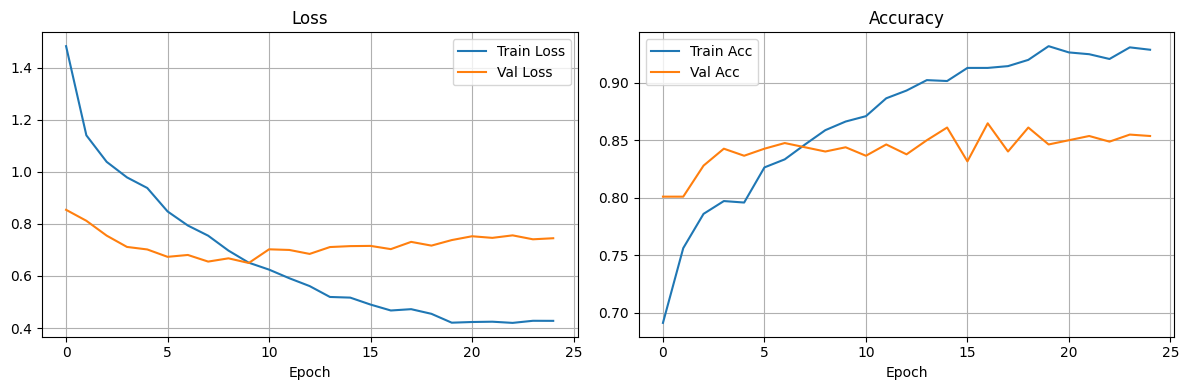

Epochs trained: 25


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"],     label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history["accuracy"],     label="Train Acc")
axes[1].plot(history.history["val_accuracy"], label="Val Acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()
print(f"Epochs trained: {len(history.history['loss'])}")

In [20]:
model.load_weights(MODEL_PATH)

y_pred_probs = model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)
test_acc     = float(np.mean(y_pred == y_test))

print(f"Test Accuracy: {test_acc*100:.2f}%\n")
print(classification_report(y_test, y_pred,
                            target_names=LABEL_NAMES,
                            labels=list(range(N_CLASSES)),
                            zero_division=0))

print("\nPer-class detail:")
for i, name in enumerate(LABEL_NAMES):
    mask      = y_test == i
    n_total   = int(np.sum(mask))
    n_correct = int(np.sum(y_pred[mask] == i))
    recall    = n_correct / n_total * 100 if n_total > 0 else 0
    print(f"  {name:10s}: {n_correct}/{n_total} correct ({recall:.1f}% recall)")

Test Accuracy: 81.85%

              precision    recall  f1-score   support

        fall       0.80      0.89      0.84       420
    non_fall       0.85      0.74      0.79       368

    accuracy                           0.82       788
   macro avg       0.82      0.81      0.82       788
weighted avg       0.82      0.82      0.82       788


Per-class detail:
  fall      : 372/420 correct (88.6% recall)
  non_fall  : 273/368 correct (74.2% recall)


In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=list(range(N_CLASSES)))

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(LABEL_NAMES)
ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(LABEL_NAMES)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix — Binary Fall Detection v5")

thresh = cm.max() / 2
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j, i, f"{cm[i,j]}", ha="center", va="center",
                color="white" if cm[i,j] > thresh else "black")

plt.tight_layout()
plt.savefig(CM_PATH, dpi=150)
plt.show()
print(f"Saved: {CM_PATH}")

epochs_trained = len(history.history["loss"])

report = {
    "version":        "binary_v5",
    "created_at":     datetime.now().isoformat(),
    "sequence_len":   SEQUENCE_LEN,
    "n_features":     N_FEATURES,
    "n_classes":      N_CLASSES,
    "label_names":    LABEL_NAMES,
    "epochs_trained": epochs_trained,
    "test_accuracy":  round(test_acc, 4),
    "n_train":        len(X_train),
    "n_val":          len(X_val),
    "n_test":         len(X_test),
}
with open(REPORT_PATH, "w") as f:
    json.dump(report, f, indent=2, ensure_ascii=False)

print("=" * 50)
print(f"  Test Accuracy  : {test_acc*100:.2f}%")
print(f"  Epochs trained : {epochs_trained}")
print(f"  Model          : {MODEL_PATH}")
print(f"  Scaler         : {SCALER_PATH}")
print(f"  Report         : {REPORT_PATH}")
print("=" * 50)

In [ ]:
epochs_trained = len(history.history["loss"])

report = {
    "version":        "3class_v1",
    "created_at":     datetime.now().isoformat(),
    "sequence_len":   SEQUENCE_LEN,
    "n_features":     N_FEATURES,
    "n_classes":      N_CLASSES,
    "label_names":    LABEL_NAMES,
    "epochs_trained": epochs_trained,
    "test_accuracy":  round(test_acc, 4),
    "n_train":        len(X_train),
    "n_val":          len(X_val),
    "n_test":         len(X_test),
}
with open(REPORT_PATH, "w") as f:
    json.dump(report, f, indent=2, ensure_ascii=False)

print("=" * 50)
print(f"  Test Accuracy  : {test_acc*100:.2f}%")
print(f"  Epochs trained : {epochs_trained}")
print(f"  Classes        : {LABEL_NAMES}")
print(f"  Model          : {MODEL_PATH}")
print(f"  Scaler         : {SCALER_PATH}")
print(f"  Report         : {REPORT_PATH}")
print("=" * 50)